<a href="https://colab.research.google.com/github/M-Khalid16/PhotonicsAILab_projects/blob/main/Bend_Insensitive_fiber.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Initial design parameters
--------------------------------------------------
core_radius_um                : 4.05
trench_inner_radius_um        : 7.1
trench_width_um               : 3.8
cladding_radius_um            : 62.5
n_clad_1310                   : 1.4469
n_clad_1550                   : 1.444
delta_core_percent            : 0.34
trench_delta_percent          : -0.16
core_dopant                   : GeO2-doped silica
trench_dopant                 : F-doped silica
cladding_material             : Pure silica

Initial computed report
--------------------------------------------------
n_core_1310                   : 1.451811
n_clad_1310                   : 1.446900
n_trench_1310                 : 1.444583
n_core_1550                   : 1.448901
n_clad_1550                   : 1.444000
n_trench_1550                 : 1.441688
NA_1310                       : 0.119314
NA_1550                       : 0.119075
V_1310                        : 2.317697
V_1550                        : 1.95490

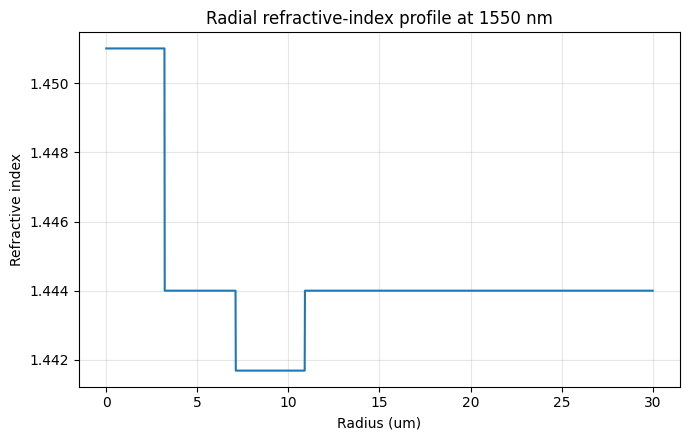

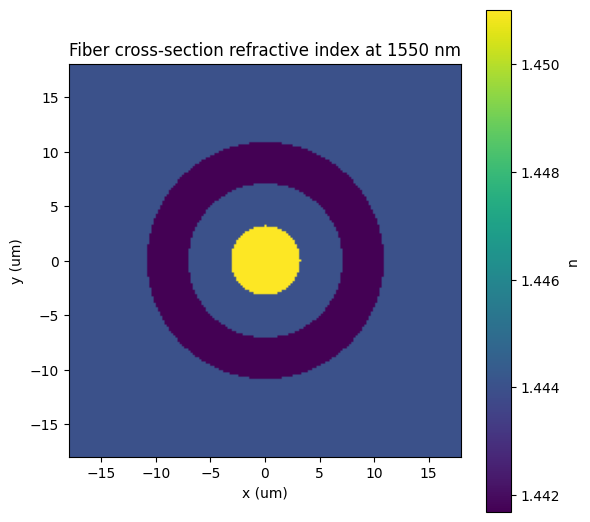

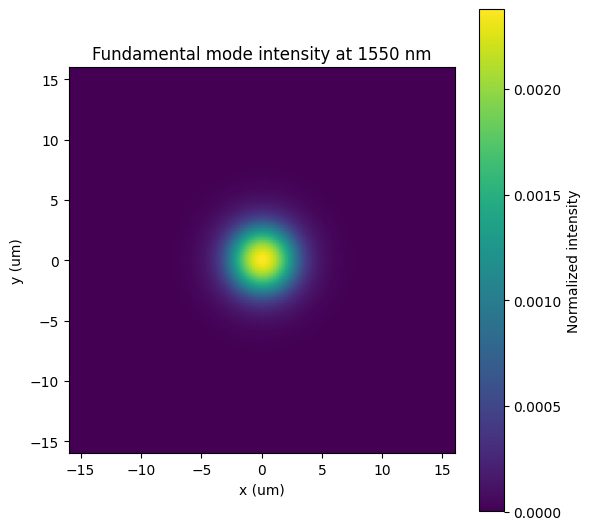

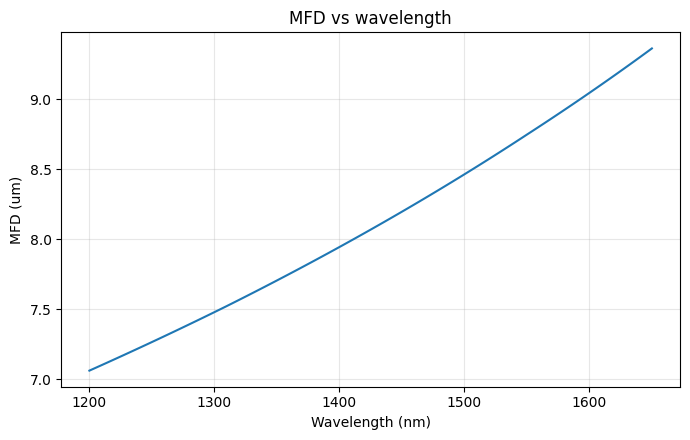

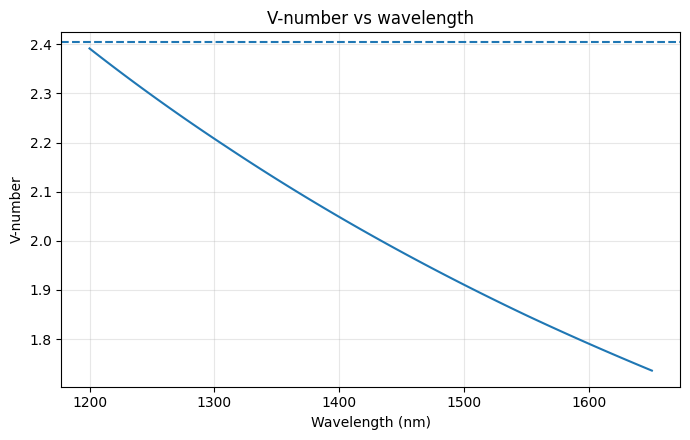

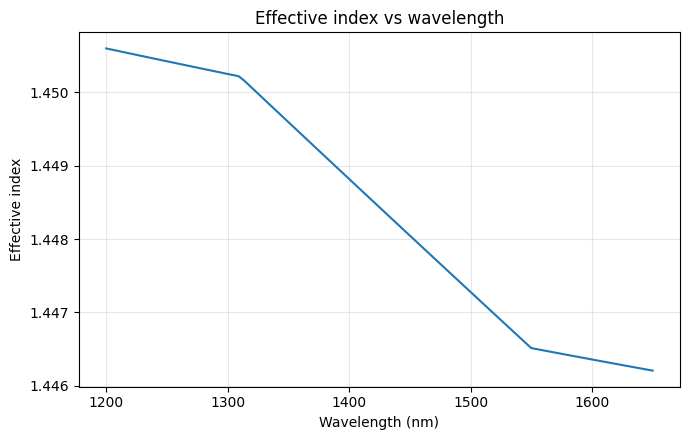

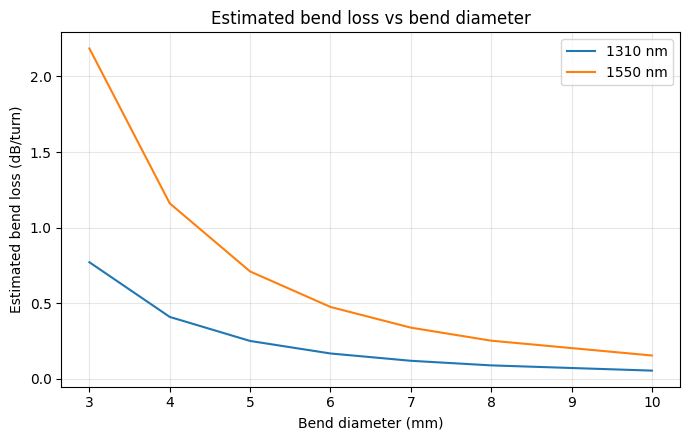


Files generated:
- radial_index_profile.png
- fiber_cross_section.png
- mode_intensity_1550.png
- fiber_mfd_vs_wavelength.png
- fiber_v_vs_wavelength.png
- fiber_neff_vs_wavelength.png
- fiber_bend_loss.png
- radial_profile.csv
- fiber_design_report.txt

Use COMSOL for final full-vector bend-loss verification before industry handoff.


In [ ]:
import math
from dataclasses import dataclass, asdict
from typing import Dict, List, Tuple

import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize, sparse
from scipy.sparse.linalg import eigsh


# ============================================================================
# University-side bend-insensitive single-mode fiber design simulator
# ----------------------------------------------------------------------------
# What this tool is for
# - Rapid pre-design of trench-assisted / depressed-cladding bend-insensitive SMF
# - Parametric optimization against target specs
# - Generate figures and tables suitable for internal review
# - Produce a design package to verify in COMSOL before sending to industry
#
# What this tool is NOT
# - A replacement for full-vector FEM bend-loss validation
# - A fabrication sign-off tool by itself
#
# Recommended workflow
#   Python simulator -> parameter screening -> COMSOL verification -> industry
# ============================================================================

PI = math.pi


@dataclass
class FiberTargets:
    wavelength_nm: Tuple[float, float] = (1310.0, 1550.0)
    cladding_diameter_um: float = 125.0
    coating_diameter_um: float = 250.0
    cutoff_nm_max: float = 1180.0
    mfd_1310_um: float = 7.15
    attenuation_1310_db_km_max: float = 0.43
    attenuation_1550_db_km_max: float = 0.27

    # From attached spec sheet: macro bend loss targets
    max_bend_loss_db_turn_1310_3mm: float = 1.0
    max_bend_loss_db_turn_1310_5mm: float = 0.5
    max_bend_loss_db_turn_1310_7mm: float = 0.2
    max_bend_loss_db_turn_1550_3mm: float = 6.0
    max_bend_loss_db_turn_1550_5mm: float = 2.5
    max_bend_loss_db_turn_1550_7mm: float = 1.0


@dataclass
class FiberDesign:
    # Geometrical design parameters in micrometers
    core_radius_um: float = 4.05
    trench_inner_radius_um: float = 7.1
    trench_width_um: float = 3.8
    cladding_radius_um: float = 62.5

    # Refractive-index parameters
    n_clad_1310: float = 1.4469
    n_clad_1550: float = 1.4440
    delta_core_percent: float = 0.34
    trench_delta_percent: float = -0.16

    # Material labels for design handoff notes
    core_dopant: str = "GeO2-doped silica"
    trench_dopant: str = "F-doped silica"
    cladding_material: str = "Pure silica"


class BendInsensitiveFiberSimulator:
    def __init__(self, design: FiberDesign, targets: FiberTargets | None = None):
        self.design = design
        self.targets = targets or FiberTargets()

    # ---------------------------------------------------------------------
    # Refractive indices
    # ---------------------------------------------------------------------
    def n_clad(self, wavelength_nm: float) -> float:
        # Simple interpolation between 1310 and 1550 nm cladding values.
        x1, x2 = 1310.0, 1550.0
        y1, y2 = self.design.n_clad_1310, self.design.n_clad_1550
        if wavelength_nm <= x1:
            return y1
        if wavelength_nm >= x2:
            return y2
        return y1 + (y2 - y1) * (wavelength_nm - x1) / (x2 - x1)

    def n_core(self, wavelength_nm: float) -> float:
        nc = self.n_clad(wavelength_nm)
        return nc * math.sqrt(1.0 + 2.0 * self.design.delta_core_percent / 100.0)

    def n_trench(self, wavelength_nm: float) -> float:
        nc = self.n_clad(wavelength_nm)
        return nc * math.sqrt(1.0 + 2.0 * self.design.trench_delta_percent / 100.0)

    def numerical_aperture(self, wavelength_nm: float) -> float:
        nco = self.n_core(wavelength_nm)
        ncl = self.n_clad(wavelength_nm)
        return math.sqrt(max(nco**2 - ncl**2, 0.0))

    # ---------------------------------------------------------------------
    # Standard step-index estimates used in early design screening
    # ---------------------------------------------------------------------
    def v_number(self, wavelength_nm: float) -> float:
        a = self.design.core_radius_um * 1e-6
        lam = wavelength_nm * 1e-9
        na = self.numerical_aperture(wavelength_nm)
        return 2.0 * PI * a * na / lam

    def cutoff_wavelength_nm(self) -> float:
        a = self.design.core_radius_um * 1e-6
        na = self.numerical_aperture(1310.0)
        lam_c = 2.0 * PI * a * na / 2.405
        return lam_c * 1e9

    def marcuse_mode_radius_um(self, wavelength_nm: float) -> float:
        V = self.v_number(wavelength_nm)
        a = self.design.core_radius_um
        if V <= 0:
            return float("nan")
        w_over_a = 0.65 + 1.619 / (V ** 1.5) + 2.879 / (V ** 6)
        return a * w_over_a

    def mode_field_diameter_um(self, wavelength_nm: float) -> float:
        return 2.0 * self.marcuse_mode_radius_um(wavelength_nm)

    # ---------------------------------------------------------------------
    # Radial refractive-index profile
    # ---------------------------------------------------------------------
    def radial_profile(self, r_um: np.ndarray, wavelength_nm: float = 1550.0) -> np.ndarray:
        n = np.full_like(r_um, self.n_clad(wavelength_nm), dtype=float)
        n[r_um <= self.design.core_radius_um] = self.n_core(wavelength_nm)

        trench_start = self.design.trench_inner_radius_um
        trench_end = trench_start + self.design.trench_width_um
        trench_mask = (r_um >= trench_start) & (r_um <= trench_end)
        n[trench_mask] = self.n_trench(wavelength_nm)
        return n

    def index_profile_summary(self) -> Dict[str, float]:
        return {
            "core_radius_um": self.design.core_radius_um,
            "trench_inner_radius_um": self.design.trench_inner_radius_um,
            "trench_outer_radius_um": self.design.trench_inner_radius_um + self.design.trench_width_um,
            "cladding_radius_um": self.design.cladding_radius_um,
            "delta_core_percent": self.design.delta_core_percent,
            "trench_delta_percent": self.design.trench_delta_percent,
        }

    # ---------------------------------------------------------------------
    # 2D cross section for visualization and scalar mode solving
    # ---------------------------------------------------------------------
    def make_cross_section(self, wavelength_nm: float = 1550.0, grid_half_width_um: float = 20.0, dx_um: float = 0.25) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
        x = np.arange(-grid_half_width_um, grid_half_width_um + dx_um, dx_um)
        y = np.arange(-grid_half_width_um, grid_half_width_um + dx_um, dx_um)
        X, Y = np.meshgrid(x, y)
        R = np.sqrt(X**2 + Y**2)

        n = np.full_like(R, self.n_clad(wavelength_nm), dtype=float)
        n[R <= self.design.core_radius_um] = self.n_core(wavelength_nm)

        trench_start = self.design.trench_inner_radius_um
        trench_end = trench_start + self.design.trench_width_um
        trench_mask = (R >= trench_start) & (R <= trench_end)
        n[trench_mask] = self.n_trench(wavelength_nm)
        return x, y, n

    # ---------------------------------------------------------------------
    # Scalar finite-difference mode solver
    # ---------------------------------------------------------------------
    def solve_scalar_fundamental_mode(self, wavelength_nm: float = 1550.0, grid_half_width_um: float = 16.0, dx_um: float = 0.25) -> Dict[str, np.ndarray | float]:
        x = np.arange(-grid_half_width_um, grid_half_width_um + dx_um, dx_um)
        y = np.arange(-grid_half_width_um, grid_half_width_um + dx_um, dx_um)
        nx, ny = len(x), len(y)

        X, Y = np.meshgrid(x, y)
        R = np.sqrt(X**2 + Y**2)
        n = np.full((ny, nx), self.n_clad(wavelength_nm), dtype=float)
        n[R <= self.design.core_radius_um] = self.n_core(wavelength_nm)

        trench_start = self.design.trench_inner_radius_um
        trench_end = trench_start + self.design.trench_width_um
        trench_mask = (R >= trench_start) & (R <= trench_end)
        n[trench_mask] = self.n_trench(wavelength_nm)

        k0 = 2.0 * PI / (wavelength_nm * 1e-9)
        dx = dx_um * 1e-6
        N = nx * ny

        main = np.full(N, -4.0 / dx**2)
        off1 = np.full(N - 1, 1.0 / dx**2)
        offn = np.full(N - nx, 1.0 / dx**2)

        # Remove wraparound links between row ends
        for i in range(1, ny):
            off1[i * nx - 1] = 0.0

        lap = sparse.diags([main, off1, off1, offn, offn], [0, -1, 1, -nx, nx], format="csr")
        pot = sparse.diags((k0**2) * (n.ravel() ** 2), 0, format="csr")
        A = lap + pot

        eigvals, eigvecs = eigsh(A, k=1, which="LA")
        beta2 = float(np.real(eigvals[0]))
        beta = math.sqrt(max(beta2, 0.0))
        neff = beta / k0

        field = np.real(eigvecs[:, 0]).reshape((ny, nx))
        field = field / np.sqrt(np.sum(np.abs(field) ** 2))
        intensity = np.abs(field) ** 2

        return {
            "x_um": x,
            "y_um": y,
            "n_xy": n,
            "field": field,
            "intensity": intensity,
            "neff": neff,
        }

    def mode_field_diameter_from_field(self, wavelength_nm: float = 1550.0) -> float:
        sol = self.solve_scalar_fundamental_mode(wavelength_nm=wavelength_nm)
        x = sol["x_um"]
        y = sol["y_um"]
        intensity = sol["intensity"]
        X, Y = np.meshgrid(x, y)
        R2 = X**2 + Y**2

        denom = np.sum(intensity)
        if denom <= 0:
            return float("nan")
        second_moment_radius_sq = 2.0 * np.sum(R2 * intensity) / denom
        w_um = math.sqrt(max(second_moment_radius_sq, 0.0))
        return 2.0 * w_um

    # ---------------------------------------------------------------------
    # Semi-empirical bend-loss screening model
    # ---------------------------------------------------------------------
    def trench_strength(self) -> float:
        depth = abs(self.design.trench_delta_percent) / 100.0
        width = self.design.trench_width_um
        r0 = self.design.trench_inner_radius_um
        if r0 <= self.design.core_radius_um:
            return 0.0
        return depth * width / r0

    def bend_loss_db_turn_est(self, wavelength_nm: float, bend_diameter_mm: float) -> float:
        # Screening model only. Final acceptance must be done in COMSOL.
        mfd = self.mode_field_diameter_um(wavelength_nm)
        V = self.v_number(wavelength_nm)
        radius_mm = bend_diameter_mm / 2.0
        trench = self.trench_strength()
        confinement_factor = (mfd / max(2 * self.design.core_radius_um, 1e-9)) ** 2
        wavelength_factor = (wavelength_nm / 1310.0) ** 1.7
        curvature_factor = (3.0 / max(bend_diameter_mm, 1e-9)) ** 2.2
        trench_factor = 1.0 / (1.0 + 55.0 * trench)
        cutoff_factor = 1.0 / max(V - 1.25, 0.2)
        return 0.55 * confinement_factor * wavelength_factor * curvature_factor * trench_factor * cutoff_factor

    # ---------------------------------------------------------------------
    # Wavelength sweeps and spec comparison
    # ---------------------------------------------------------------------
    def wavelength_sweep(self, wl_start_nm: float = 1200.0, wl_stop_nm: float = 1650.0, npts: int = 100) -> Dict[str, np.ndarray]:
        wl = np.linspace(wl_start_nm, wl_stop_nm, npts)
        mfd = np.array([self.mode_field_diameter_um(w) for w in wl])
        v = np.array([self.v_number(w) for w in wl])
        neff = []
        for w in wl:
            try:
                neff.append(self.solve_scalar_fundamental_mode(wavelength_nm=float(w), grid_half_width_um=14.0, dx_um=0.35)["neff"])
            except Exception:
                neff.append(np.nan)
        return {
            "wavelength_nm": wl,
            "mfd_um": mfd,
            "v_number": v,
            "neff": np.array(neff, dtype=float),
        }

    def bend_diameter_sweep(self, wavelength_nm: float, diameters_mm: List[float]) -> Dict[str, np.ndarray]:
        d = np.array(diameters_mm, dtype=float)
        loss = np.array([self.bend_loss_db_turn_est(wavelength_nm, float(x)) for x in d])
        return {
            "diameter_mm": d,
            "bend_loss_db_turn_est": loss,
        }

    def evaluate(self) -> Dict[str, float]:
        neff_1310 = self.solve_scalar_fundamental_mode(1310.0, grid_half_width_um=14.0, dx_um=0.35)["neff"]
        neff_1550 = self.solve_scalar_fundamental_mode(1550.0, grid_half_width_um=14.0, dx_um=0.35)["neff"]
        try:
            field_mfd_1550 = self.mode_field_diameter_from_field(1550.0)
        except Exception:
            field_mfd_1550 = float("nan")

        return {
            "n_core_1310": self.n_core(1310.0),
            "n_clad_1310": self.n_clad(1310.0),
            "n_trench_1310": self.n_trench(1310.0),
            "n_core_1550": self.n_core(1550.0),
            "n_clad_1550": self.n_clad(1550.0),
            "n_trench_1550": self.n_trench(1550.0),
            "NA_1310": self.numerical_aperture(1310.0),
            "NA_1550": self.numerical_aperture(1550.0),
            "V_1310": self.v_number(1310.0),
            "V_1550": self.v_number(1550.0),
            "cutoff_nm_est": self.cutoff_wavelength_nm(),
            "MFD_1310_um_est": self.mode_field_diameter_um(1310.0),
            "MFD_1550_um_est": self.mode_field_diameter_um(1550.0),
            "MFD_1550_um_from_field": field_mfd_1550,
            "neff_1310": neff_1310,
            "neff_1550": neff_1550,
            "bend_loss_db_turn_1310_3mm_est": self.bend_loss_db_turn_est(1310.0, 3.0),
            "bend_loss_db_turn_1310_5mm_est": self.bend_loss_db_turn_est(1310.0, 5.0),
            "bend_loss_db_turn_1310_7mm_est": self.bend_loss_db_turn_est(1310.0, 7.0),
            "bend_loss_db_turn_1550_3mm_est": self.bend_loss_db_turn_est(1550.0, 3.0),
            "bend_loss_db_turn_1550_5mm_est": self.bend_loss_db_turn_est(1550.0, 5.0),
            "bend_loss_db_turn_1550_7mm_est": self.bend_loss_db_turn_est(1550.0, 7.0),
        }

    def pass_fail(self) -> Dict[str, bool]:
        rep = self.evaluate()
        return {
            "single_mode_1310": rep["V_1310"] < 2.405,
            "single_mode_1550": rep["V_1550"] < 2.405,
            "cutoff_ok": rep["cutoff_nm_est"] <= self.targets.cutoff_nm_max,
            "mfd_1310_close": abs(rep["MFD_1310_um_est"] - self.targets.mfd_1310_um) <= 0.5,
            "bend_1310_3mm_ok": rep["bend_loss_db_turn_1310_3mm_est"] <= self.targets.max_bend_loss_db_turn_1310_3mm,
            "bend_1310_5mm_ok": rep["bend_loss_db_turn_1310_5mm_est"] <= self.targets.max_bend_loss_db_turn_1310_5mm,
            "bend_1310_7mm_ok": rep["bend_loss_db_turn_1310_7mm_est"] <= self.targets.max_bend_loss_db_turn_1310_7mm,
            "bend_1550_3mm_ok": rep["bend_loss_db_turn_1550_3mm_est"] <= self.targets.max_bend_loss_db_turn_1550_3mm,
            "bend_1550_5mm_ok": rep["bend_loss_db_turn_1550_5mm_est"] <= self.targets.max_bend_loss_db_turn_1550_5mm,
            "bend_1550_7mm_ok": rep["bend_loss_db_turn_1550_7mm_est"] <= self.targets.max_bend_loss_db_turn_1550_7mm,
        }

    # ---------------------------------------------------------------------
    # Objective for optimization
    # ---------------------------------------------------------------------
    def objective(self) -> float:
        rep = self.evaluate()

        mfd_err = ((rep["MFD_1310_um_est"] - self.targets.mfd_1310_um) / 0.35) ** 2
        cutoff_penalty = max(rep["cutoff_nm_est"] - self.targets.cutoff_nm_max, 0.0) / 30.0
        single_mode_penalty = max(rep["V_1310"] - 2.405, 0.0) * 8.0

        bend_penalty = 0.0
        bend_penalty += max(rep["bend_loss_db_turn_1310_3mm_est"] - self.targets.max_bend_loss_db_turn_1310_3mm, 0.0) * 8.0
        bend_penalty += max(rep["bend_loss_db_turn_1310_5mm_est"] - self.targets.max_bend_loss_db_turn_1310_5mm, 0.0) * 8.0
        bend_penalty += max(rep["bend_loss_db_turn_1310_7mm_est"] - self.targets.max_bend_loss_db_turn_1310_7mm, 0.0) * 8.0
        bend_penalty += max(rep["bend_loss_db_turn_1550_3mm_est"] - self.targets.max_bend_loss_db_turn_1550_3mm, 0.0) * 3.0
        bend_penalty += max(rep["bend_loss_db_turn_1550_5mm_est"] - self.targets.max_bend_loss_db_turn_1550_5mm, 0.0) * 3.0
        bend_penalty += max(rep["bend_loss_db_turn_1550_7mm_est"] - self.targets.max_bend_loss_db_turn_1550_7mm, 0.0) * 3.0

        return mfd_err + cutoff_penalty**2 + single_mode_penalty**2 + bend_penalty


# -------------------------------------------------------------------------
# Optimization helper
# -------------------------------------------------------------------------
def optimize_design(initial: FiberDesign, targets: FiberTargets | None = None) -> Tuple[FiberDesign, Dict[str, float]]:
    targets = targets or FiberTargets()

    def pack(d: FiberDesign) -> np.ndarray:
        return np.array([
            d.core_radius_um,
            d.delta_core_percent,
            d.trench_inner_radius_um,
            d.trench_width_um,
            d.trench_delta_percent,
        ], dtype=float)

    def unpack(x: np.ndarray) -> FiberDesign:
        return FiberDesign(
            core_radius_um=float(x[0]),
            delta_core_percent=float(x[1]),
            trench_inner_radius_um=float(x[2]),
            trench_width_um=float(x[3]),
            trench_delta_percent=float(x[4]),
            cladding_radius_um=initial.cladding_radius_um,
            n_clad_1310=initial.n_clad_1310,
            n_clad_1550=initial.n_clad_1550,
            core_dopant=initial.core_dopant,
            trench_dopant=initial.trench_dopant,
            cladding_material=initial.cladding_material,
        )

    def fun(x: np.ndarray) -> float:
        d = unpack(x)
        if d.core_radius_um <= 0:
            return 1e6
        if d.trench_width_um <= 0:
            return 1e6
        if d.trench_inner_radius_um <= d.core_radius_um + 0.25:
            return 1e6
        sim = BendInsensitiveFiberSimulator(d, targets)
        return sim.objective()

    x0 = pack(initial)
    bounds = [
        (3.2, 5.0),
        (0.20, 0.65),
        (5.3, 12.0),
        (1.5, 7.0),
        (-0.35, -0.03),
    ]

    result = optimize.minimize(fun, x0, method="L-BFGS-B", bounds=bounds)
    best = unpack(result.x)
    rep = BendInsensitiveFiberSimulator(best, targets).evaluate()
    rep["objective"] = float(result.fun)
    rep["optimizer_success"] = bool(result.success)
    return best, rep


# -------------------------------------------------------------------------
# Plotting
# -------------------------------------------------------------------------
def plot_radial_index_profile(sim: BendInsensitiveFiberSimulator, wavelength_nm: float = 1550.0, savepath: str | None = None) -> None:
    r = np.linspace(0, 30, 2000)
    n = sim.radial_profile(r, wavelength_nm=wavelength_nm)
    plt.figure(figsize=(7, 4.5))
    plt.plot(r, n)
    plt.xlabel("Radius (um)")
    plt.ylabel("Refractive index")
    plt.title(f"Radial refractive-index profile at {wavelength_nm:.0f} nm")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=200)
    plt.show()


def plot_cross_section(sim: BendInsensitiveFiberSimulator, wavelength_nm: float = 1550.0, savepath: str | None = None) -> None:
    x, y, n = sim.make_cross_section(wavelength_nm=wavelength_nm, grid_half_width_um=18.0, dx_um=0.2)
    plt.figure(figsize=(6, 5.5))
    plt.imshow(n, origin="lower", extent=[x.min(), x.max(), y.min(), y.max()], aspect="equal")
    plt.xlabel("x (um)")
    plt.ylabel("y (um)")
    plt.title(f"Fiber cross-section refractive index at {wavelength_nm:.0f} nm")
    plt.colorbar(label="n")
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=200)
    plt.show()


def plot_mode_intensity(sim: BendInsensitiveFiberSimulator, wavelength_nm: float = 1550.0, savepath: str | None = None) -> None:
    sol = sim.solve_scalar_fundamental_mode(wavelength_nm=wavelength_nm)
    x = sol["x_um"]
    y = sol["y_um"]
    intensity = sol["intensity"]
    plt.figure(figsize=(6, 5.5))
    plt.imshow(intensity, origin="lower", extent=[x.min(), x.max(), y.min(), y.max()], aspect="equal")
    plt.xlabel("x (um)")
    plt.ylabel("y (um)")
    plt.title(f"Fundamental mode intensity at {wavelength_nm:.0f} nm")
    plt.colorbar(label="Normalized intensity")
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=200)
    plt.show()


def plot_wavelength_sweeps(sim: BendInsensitiveFiberSimulator, save_prefix: str | None = None) -> None:
    data = sim.wavelength_sweep()

    plt.figure(figsize=(7, 4.5))
    plt.plot(data["wavelength_nm"], data["mfd_um"])
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("MFD (um)")
    plt.title("MFD vs wavelength")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    if save_prefix:
        plt.savefig(f"{save_prefix}_mfd_vs_wavelength.png", dpi=200)
    plt.show()

    plt.figure(figsize=(7, 4.5))
    plt.plot(data["wavelength_nm"], data["v_number"])
    plt.axhline(2.405, linestyle="--")
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("V-number")
    plt.title("V-number vs wavelength")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    if save_prefix:
        plt.savefig(f"{save_prefix}_v_vs_wavelength.png", dpi=200)
    plt.show()

    plt.figure(figsize=(7, 4.5))
    plt.plot(data["wavelength_nm"], data["neff"])
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Effective index")
    plt.title("Effective index vs wavelength")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    if save_prefix:
        plt.savefig(f"{save_prefix}_neff_vs_wavelength.png", dpi=200)
    plt.show()


def plot_bend_loss(sim: BendInsensitiveFiberSimulator, save_prefix: str | None = None) -> None:
    diam = [3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 10.0]
    d1 = sim.bend_diameter_sweep(1310.0, diam)
    d2 = sim.bend_diameter_sweep(1550.0, diam)

    plt.figure(figsize=(7, 4.5))
    plt.plot(d1["diameter_mm"], d1["bend_loss_db_turn_est"], label="1310 nm")
    plt.plot(d2["diameter_mm"], d2["bend_loss_db_turn_est"], label="1550 nm")
    plt.xlabel("Bend diameter (mm)")
    plt.ylabel("Estimated bend loss (dB/turn)")
    plt.title("Estimated bend loss vs bend diameter")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    if save_prefix:
        plt.savefig(f"{save_prefix}_bend_loss.png", dpi=200)
    plt.show()


# -------------------------------------------------------------------------
# Report export
# -------------------------------------------------------------------------
def generate_design_report(sim: BendInsensitiveFiberSimulator, filename: str = "fiber_design_report.txt") -> None:
    rep = sim.evaluate()
    pf = sim.pass_fail()
    info = sim.index_profile_summary()

    with open(filename, "w", encoding="utf-8") as f:
        f.write("BEND-INSENSITIVE SINGLE-MODE FIBER DESIGN REPORT\n")
        f.write("=" * 60 + "\n\n")
        f.write("Design parameters\n")
        f.write("-" * 30 + "\n")
        for k, v in asdict(sim.design).items():
            f.write(f"{k:30s}: {v}\n")

        f.write("\nIndex profile summary\n")
        f.write("-" * 30 + "\n")
        for k, v in info.items():
            f.write(f"{k:30s}: {v}\n")

        f.write("\nComputed parameters\n")
        f.write("-" * 30 + "\n")
        for k, v in rep.items():
            f.write(f"{k:30s}: {v:.6f}\n")

        f.write("\nPass/fail screening\n")
        f.write("-" * 30 + "\n")
        for k, v in pf.items():
            f.write(f"{k:30s}: {v}\n")

        f.write("\nRecommended COMSOL verification items\n")
        f.write("-" * 30 + "\n")
        f.write("1. Full-vector eigenmode validation at 1310 and 1550 nm\n")
        f.write("2. Macro-bending loss validation at 3 mm, 5 mm, 7 mm bend diameters\n")
        f.write("3. Sensitivity analysis for trench depth, trench width, and trench radius\n")
        f.write("4. Fabrication tolerance analysis for delta_core and trench_delta\n")
        f.write("5. Final refractive-index profile export for preform/fiber fabrication discussion\n")


# -------------------------------------------------------------------------
# Example usage
# -------------------------------------------------------------------------
def main() -> None:
    initial = FiberDesign(
        core_radius_um=4.05,
        trench_inner_radius_um= 7.10, #4.05, #7.10,
        trench_width_um=3.80, #6.85, #3.80,
        cladding_radius_um=62.5,
        n_clad_1310=1.4469,
        n_clad_1550=1.4440,
        delta_core_percent=0.34,
        trench_delta_percent= -0.30,# -0.12, -0.16, -0.20, -0.25, -0.30, #-0.16,
    )
    targets = FiberTargets()

    sim = BendInsensitiveFiberSimulator(initial, targets)

    print("Initial design parameters")
    print("-" * 50)
    for k, v in asdict(initial).items():
        print(f"{k:30s}: {v}")

    print("\nInitial computed report")
    print("-" * 50)
    initial_report = sim.evaluate()
    for k, v in initial_report.items():
        print(f"{k:30s}: {v:.6f}")

    print("\nInitial pass/fail")
    print("-" * 50)
    for k, v in sim.pass_fail().items():
        print(f"{k:30s}: {v}")

    best_design, best_report = optimize_design(initial, targets)
    print("\nOptimized design")
    print("-" * 50)
    for k, v in asdict(best_design).items():
        print(f"{k:30s}: {v}")

    print("\nOptimized computed report")
    print("-" * 50)
    for k, v in best_report.items():
        if isinstance(v, bool):
            print(f"{k:30s}: {v}")
        else:
            print(f"{k:30s}: {v:.6f}")

    best_sim = BendInsensitiveFiberSimulator(best_design, targets)

    # Generate figures
    plot_radial_index_profile(best_sim, wavelength_nm=1550.0, savepath="radial_index_profile.png")
    plot_cross_section(best_sim, wavelength_nm=1550.0, savepath="fiber_cross_section.png")
    plot_mode_intensity(best_sim, wavelength_nm=1550.0, savepath="mode_intensity_1550.png")
    plot_wavelength_sweeps(best_sim, save_prefix="fiber")
    plot_bend_loss(best_sim, save_prefix="fiber")

    # Export raw radial profile data
    r = np.linspace(0, 30, 2000)
    n = best_sim.radial_profile(r, wavelength_nm=1550.0)
    np.savetxt(
        "radial_profile.csv",
        np.column_stack([r, n]),
        delimiter=",",
        header="radius_um,refractive_index",
        comments="",
    )

    generate_design_report(best_sim, filename="fiber_design_report.txt")

    print("\nFiles generated:")
    print("- radial_index_profile.png")
    print("- fiber_cross_section.png")
    print("- mode_intensity_1550.png")
    print("- fiber_mfd_vs_wavelength.png")
    print("- fiber_v_vs_wavelength.png")
    print("- fiber_neff_vs_wavelength.png")
    print("- fiber_bend_loss.png")
    print("- radial_profile.csv")
    print("- fiber_design_report.txt")

    print("\nUse COMSOL for final full-vector bend-loss verification before industry handoff.")


if __name__ == "__main__":
    main()
